# Cutting Phase Analysis

## Project goal
This project analyzes body weight trends, calorie intake, protein intake, activity, and estimated calorie deficit during my cutting phase.

## Scope note
This analysis focuses on the active cutting phase. Early February entries before consistent cutting and nutrition logging began were excluded from the final dataset.

## 1. Load and prepare the data

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw_cut_data.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df.head()

,date,weight_kg,trend_weight_kg,calories_kcal,protein_g,fat_g,carbs_g,target_calories_kcal,target_protein_g,target_fat_g,target_carbs_g,expenditure_kcal,steps,notes
0,2026-02-11,94.0,93.85,2161.0,124.0,62.0,293.0,1738.0,239.0,57.0,64.0,2462,13835,NaN
1,2026-02-12,92.4,93.70,1825.0,149.0,58.0,178.0,1738.0,199.0,57.0,104.0,2462,15332,NaN
2,2026-02-13,91.7,93.50,2326.0,205.0,117.0,112.0,1738.0,199.0,57.0,104.0,2462,12643,NaN
3,2026-02-14,NaN,93.30,1772.0,192.0,39.0,159.0,1738.0,199.0,57.0,104.0,2464,14549,NaN
4,2026-02-15,NaN,93.09,1824.0,182.0,60.0,144.0,1738.0,199.0,57.0,104.0,2467,4208,NaN


In [20]:
print(df["date"].min())
print(df["date"].max())
print(df.shape)
print(df["date"].duplicated().sum())

2026-02-11 00:00:00
2026-03-25 00:00:00
(43, 14)
0


## 2. Body Weight Trend

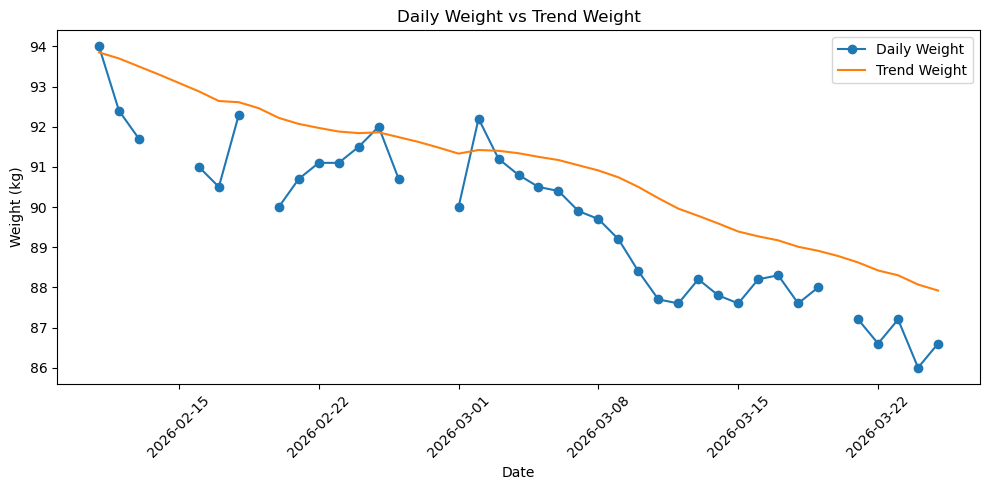

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["weight_kg"], marker="o", label="Daily Weight")
plt.plot(df["date"], df["trend_weight_kg"], label="Trend Weight")
plt.xlabel("Date")
plt.ylabel("Weight (kg)")
plt.title("Daily Weight vs Trend Weight")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Body weight observations
- Daily body weight fluctuated noticeably across the cutting phase.
- Trend weight provided a clearer view of overall progress than individual weigh-ins.
- Despite short-term spikes, the general direction of body weight was downward.

## 3. Estimated Calorie Deficit

In [22]:
df["estimated_deficit_kcal"] = df["expenditure_kcal"] - df["calories_kcal"]

df[["date", "calories_kcal", "expenditure_kcal", "estimated_deficit_kcal"]].head()

,date,calories_kcal,expenditure_kcal,estimated_deficit_kcal
0,2026-02-11,2161.0,2462,301.0
1,2026-02-12,1825.0,2462,637.0
2,2026-02-13,2326.0,2462,136.0
3,2026-02-14,1772.0,2464,692.0
4,2026-02-15,1824.0,2467,643.0


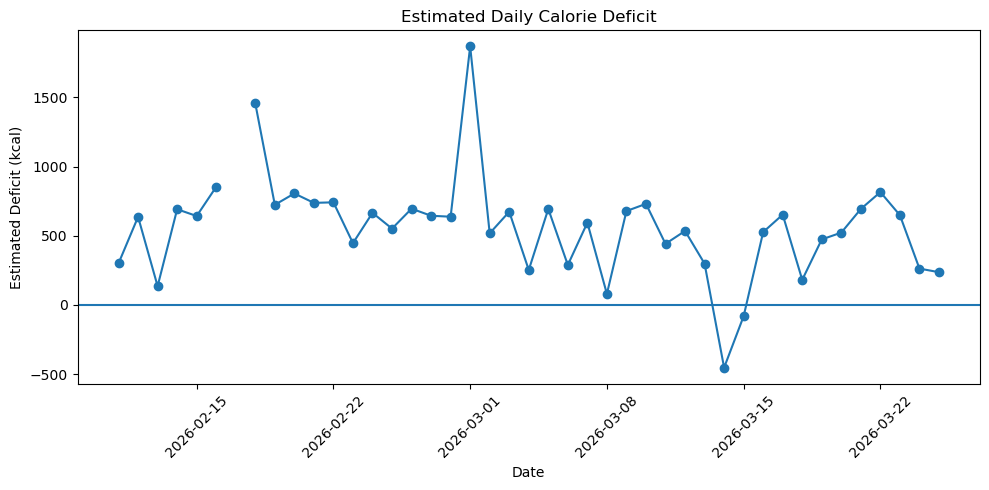

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["estimated_deficit_kcal"], marker="o")
plt.axhline(0)
plt.xlabel("Date")
plt.ylabel("Estimated Deficit (kcal)")
plt.title("Estimated Daily Calorie Deficit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
print("Average daily estimated deficit:", round(df["estimated_deficit_kcal"].mean(), 1), "kcal")
print("Total estimated deficit:", round(df["estimated_deficit_kcal"].sum(), 1), "kcal")

Average daily estimated deficit: 559.9 kcal
Total estimated deficit: 23516.0 kcal


## Estimated deficit observations
- Estimated deficit is calculated as expenditure minus calorie intake.
- Positive values suggest a calorie deficit, while negative values suggest a surplus.
- This helps compare expected fat-loss conditions with the actual body weight trend.

## 4. Actual vs Target Calories

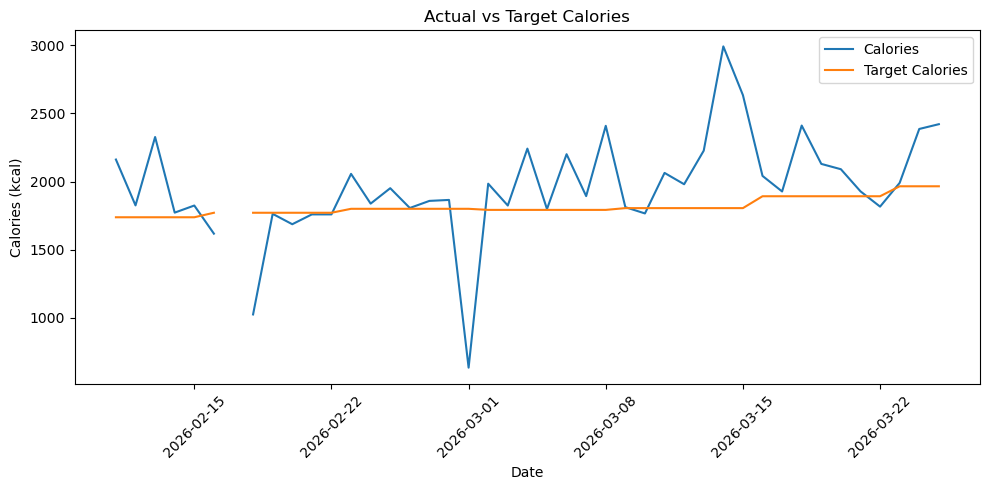

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["calories_kcal"], label="Calories")
plt.plot(df["date"], df["target_calories_kcal"], label="Target Calories")
plt.xlabel("Date")
plt.ylabel("Calories (kcal)")
plt.title("Actual vs Target Calories")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Actual vs Target Protein 
This section compares my daily protein intake with my target protein intake during the cutting phase.

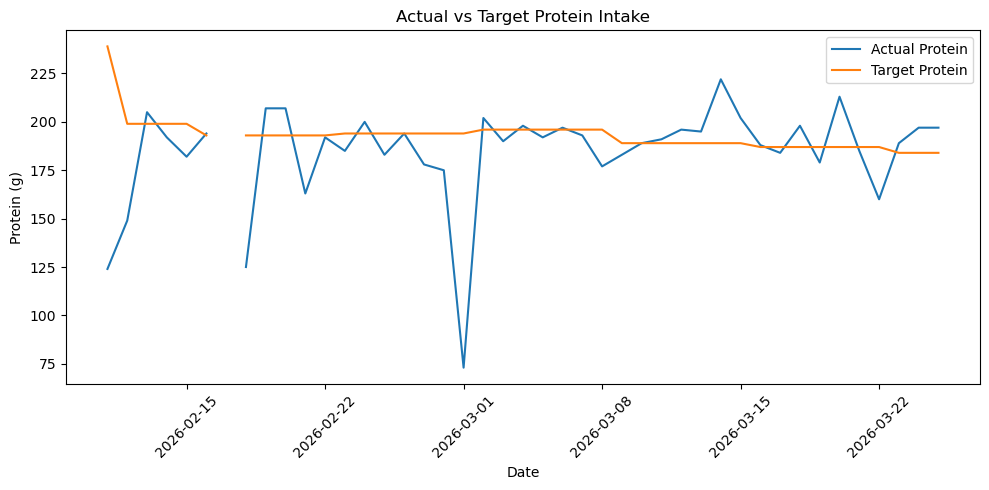

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["protein_g"], label="Actual Protein")
plt.plot(df["date"], df["target_protein_g"], label="Target Protein")
plt.xlabel("Date")
plt.ylabel("Protein (g)")
plt.title("Actual vs Target Protein Intake")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
df["protein_diff_g"] = df["protein_g"] - df["target_protein_g"]

df[["date", "protein_g", "target_protein_g", "protein_diff_g"]].head()

,date,protein_g,target_protein_g,protein_diff_g
0,2026-02-11,124.0,239.0,-115.0
1,2026-02-12,149.0,199.0,-50.0
2,2026-02-13,205.0,199.0,6.0
3,2026-02-14,192.0,199.0,-7.0
4,2026-02-15,182.0,199.0,-17.0


## Protein observations
- This graph shows how consistently protein intake matched the daily target.
- Days below target may indicate weaker adherence to cutting-phase nutrition goals.
- Protein intake is important to monitor during a cut because it helps support muscle retention.

## 6. Daily steps
This section shows daily step count across the month as a simple measure of movement and activity.

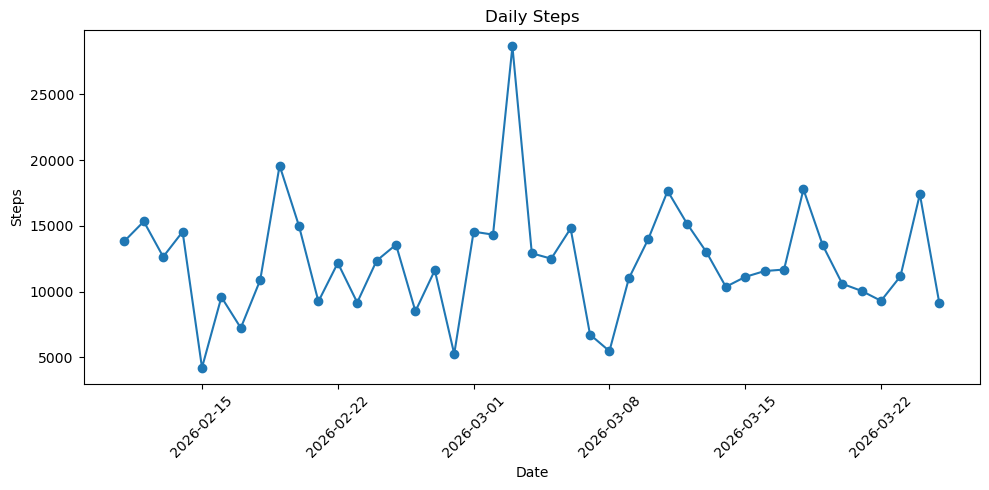

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["steps"], marker="o")
plt.xlabel("Date")
plt.ylabel("Steps")
plt.title("Daily Steps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Steps observations
- Daily steps varied noticeably across the month.
- Higher-step days may have contributed to higher energy expenditure.
- Steps provide useful context when interpreting deficit and weight trend results.

## 7. Weekly averages
Daily values can be noisy, so weekly averages help show the broader trend in weight, calorie intake, expenditure, protein intake, and steps.

In [29]:
weekly_df = df.copy()
weekly_df = weekly_df.set_index("date")

weekly_summary = weekly_df.resample("W").agg({
    "weight_kg": "mean",
    "trend_weight_kg": "mean",
    "calories_kcal": ["mean", "count"],
    "target_calories_kcal": "mean",
    "protein_g": ["mean", "count"],
    "target_protein_g": "mean",
    "estimated_deficit_kcal": ["mean", "count"],
    "steps": ["mean", "count"]
})

weekly_summary.columns = [
    "weight_kg",
    "trend_weight_kg",
    "calories_kcal",
    "calories_count",
    "target_calories_kcal",
    "protein_g",
    "protein_count",
    "target_protein_g",
    "estimated_deficit_kcal",
    "deficit_count",
    "steps",
    "steps_count"
]

weekly_summary

weekly_avg = weekly_summary[
    (weekly_summary["calories_count"] >= 5) &
    (weekly_summary["protein_count"] >= 5) &
    (weekly_summary["steps_count"] >= 5)
].copy()

weekly_avg

,weight_kg,trend_weight_kg,calories_kcal,calories_count,target_calories_kcal,protein_g,protein_count,target_protein_g,estimated_deficit_kcal,deficit_count,steps,steps_count
date,,,,,,,,,,,,
2026-02-15,92.700000,93.488000,1981.600000,5,1738.0,170.400000,5,207.0,481.800000,5,12113.400000,5
2026-02-22,90.933333,92.407143,1602.000000,6,1771.0,181.333333,6,193.0,886.833333,6,11952.857143,7
2026-03-01,91.060000,91.678571,1715.714286,7,1800.0,169.714286,7,194.0,787.571429,7,10714.142857,7
2026-03-08,90.671429,91.218571,2049.714286,7,1792.0,192.714286,7,196.0,443.285714,7,13626.000000,7
2026-03-15,88.071429,90.025714,2210.000000,7,1805.0,196.857143,7,189.0,307.428571,7,13180.714286,7
2026-03-22,87.650000,88.882857,2048.714286,7,1892.0,186.714286,7,187.0,552.714286,7,12062.714286,7


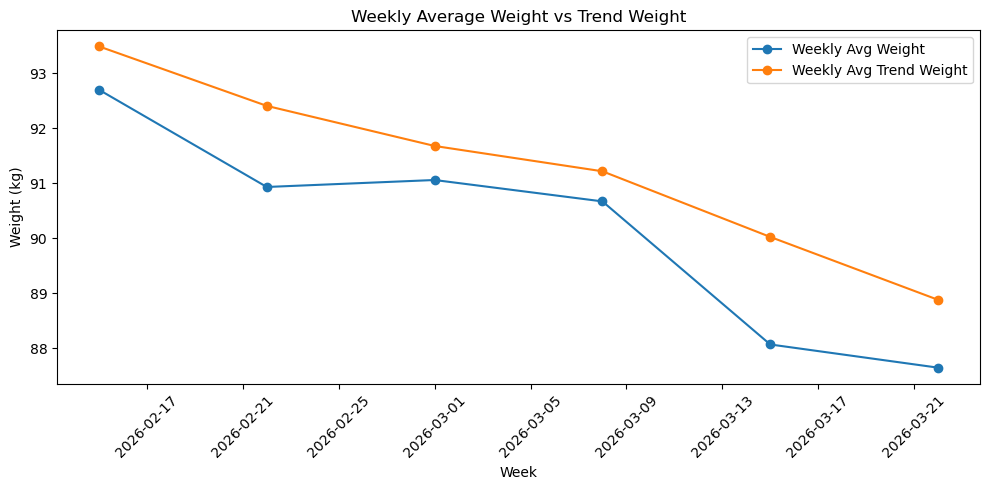

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_avg.index, weekly_avg["weight_kg"], marker="o", label="Weekly Avg Weight")
plt.plot(weekly_avg.index, weekly_avg["trend_weight_kg"], marker="o", label="Weekly Avg Trend Weight")
plt.xlabel("Week")
plt.ylabel("Weight (kg)")
plt.title("Weekly Average Weight vs Trend Weight")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

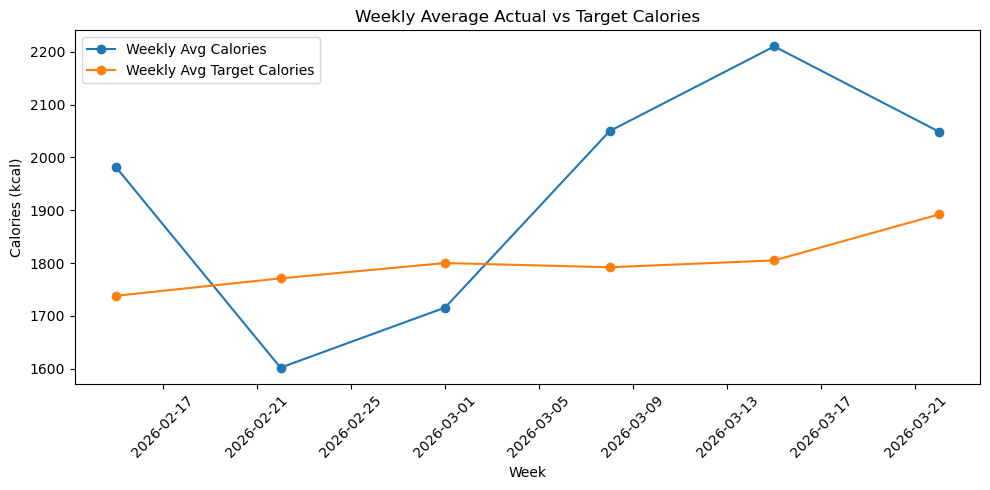

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_avg.index, weekly_avg["calories_kcal"], marker="o", label="Weekly Avg Calories")
plt.plot(weekly_avg.index, weekly_avg["target_calories_kcal"], marker="o", label="Weekly Avg Target Calories")
plt.xlabel("Week")
plt.ylabel("Calories (kcal)")
plt.title("Weekly Average Actual vs Target Calories")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

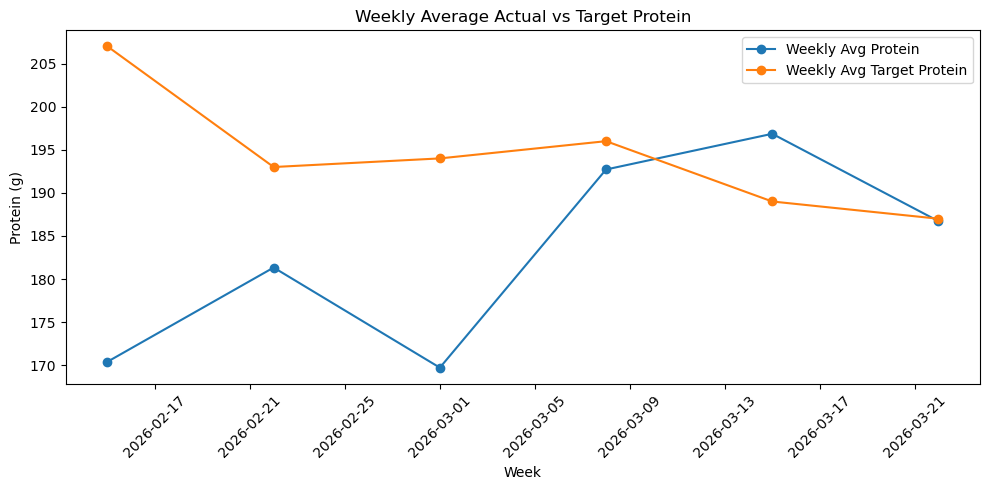

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_avg.index, weekly_avg["protein_g"], marker="o", label="Weekly Avg Protein")
plt.plot(weekly_avg.index, weekly_avg["target_protein_g"], marker="o", label="Weekly Avg Target Protein")
plt.xlabel("Week")
plt.ylabel("Protein (g)")
plt.title("Weekly Average Actual vs Target Protein")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

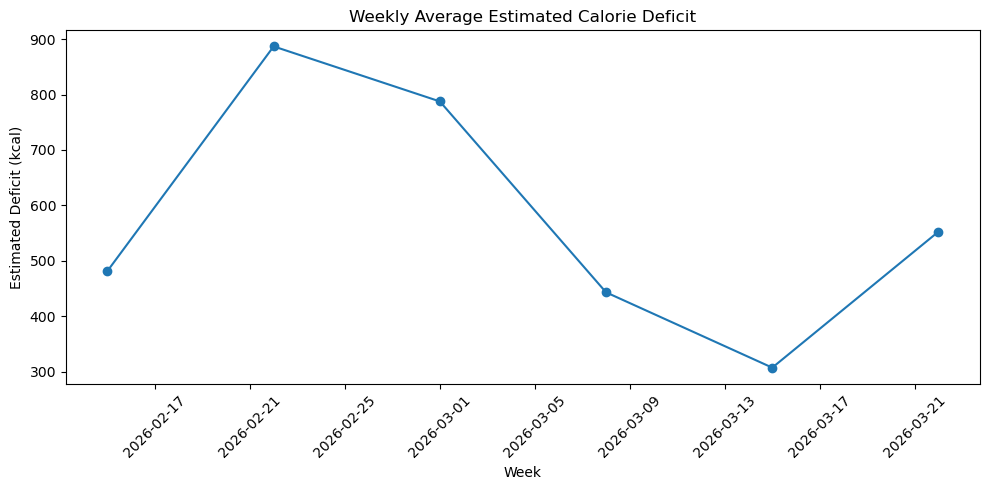

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_avg.index, weekly_avg["estimated_deficit_kcal"], marker="o")
plt.xlabel("Week")
plt.ylabel("Estimated Deficit (kcal)")
plt.title("Weekly Average Estimated Calorie Deficit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

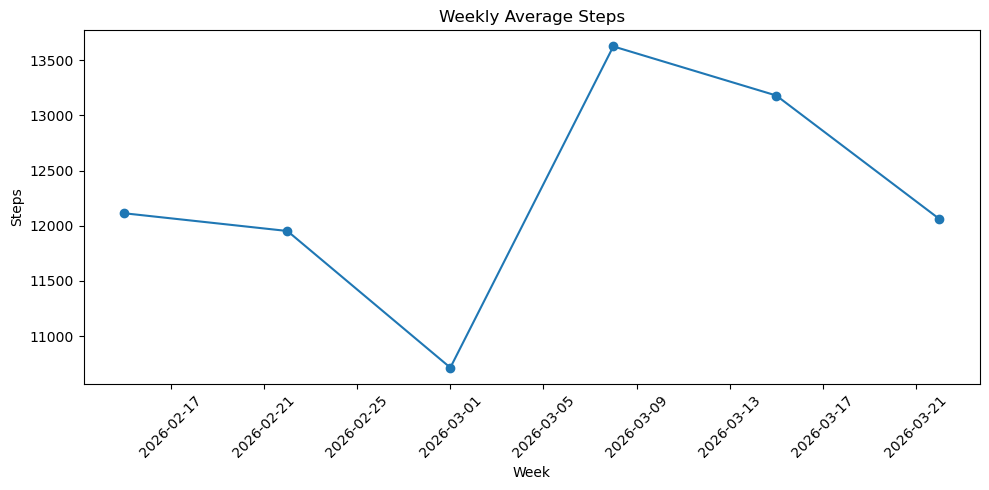

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_avg.index, weekly_avg["steps"], marker="o")
plt.xlabel("Week")
plt.ylabel("Steps")
plt.title("Weekly Average Steps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Weekly averages observations
- Weekly averages smooth out daily fluctuations and make the overall cutting trend easier to interpret.
- Weekly average weight and trend weight provide a clearer picture of progress than daily weigh-ins alone.
- Weekly average calories and protein intake make it easier to judge adherence to nutrition targets.
- Weekly average deficit and steps help explain whether activity and intake were consistent across the month.

## Weekly averages note
Incomplete edge weeks were excluded from some weekly average plots where logging was not complete enough for fair comparison. In this notebook, weeks with fewer than 5 logged days for key variables were excluded from the filtered weekly analysis.

## 8. Overall findings

- Trend weight decreased across the month, despite daily fluctuations in scale weight.
- Most days show a positive estimated calorie deficit, which is consistent with the downward weight trend.
- Actual calorie intake was often above target calories, but expenditure was still usually high enough to keep intake below expenditure.
- There was a noticeable spike in calories around mid-month, which also coincided with one of the few negative-deficit days.
- Daily weight is noisy, so trend weight appears to be a better indicator of actual cutting progress.

## Limitations
- The notes column is currently mostly blank because contextual day-level notes were not consistently recorded during the cut.

## 9. Summary Statistics

In [35]:
print("Average daily calories:", round(df["calories_kcal"].mean(), 1))
print("Average target calories:", round(df["target_calories_kcal"].mean(), 1))
print("Average daily protein:", round(df["protein_g"].mean(), 1))
print("Average target protein:", round(df["target_protein_g"].mean(), 1))
print("Average daily expenditure:", round(df["expenditure_kcal"].mean(), 1))
print("Average daily estimated deficit:", round(df["estimated_deficit_kcal"].mean(), 1))
print("Average daily steps:", round(df["steps"].mean(), 1))

print("Days above calorie target:", (df["calories_kcal"] > df["target_calories_kcal"]).sum())
print("Days meeting protein target:", (df["protein_g"] >= df["target_protein_g"]).sum())
print("Average daily fat:", round(df["fat_g"].mean(), 1))
print("Average daily carbs:", round(df["carbs_g"].mean(), 1))

print("Weight change over period:", round(df["weight_kg"].iloc[-1] - df["weight_kg"].iloc[0], 2), "kg")
print("Trend weight change over period:", round(df["trend_weight_kg"].iloc[-1] - df["trend_weight_kg"].iloc[0], 2), "kg")

Average daily calories: 1963.9
Average target calories: 1815.1
Average daily protein: 184.4
Average target protein: 193.0
Average daily expenditure: 2522.8
Average daily estimated deficit: 559.9
Average daily steps: 12303.0
Days above calorie target: 33
Days meeting protein target: 21
Average daily fat: 64.7
Average daily carbs: 146.5
Weight change over period: -7.4 kg
Trend weight change over period: -5.93 kg


## 10. Adherence metrics
This section measures how often calorie and protein intake matched their respective daily targets during the active cutting phase.

In [36]:
days_with_calorie_data = df["calories_kcal"].notna().sum()
days_with_protein_data = df["protein_g"].notna().sum()

days_above_calorie_target = (df["calories_kcal"] > df["target_calories_kcal"]).sum()
days_meeting_protein_target = (df["protein_g"] >= df["target_protein_g"]).sum()

print("Days with calorie data:", days_with_calorie_data)
print("Days above calorie target:", days_above_calorie_target)
print("Percent days above calorie target:",
      round(days_above_calorie_target / days_with_calorie_data * 100, 1), "%")

print("Days with protein data:", days_with_protein_data)
print("Days meeting protein target:", days_meeting_protein_target)
print("Percent days meeting protein target:",
      round(days_meeting_protein_target / days_with_protein_data * 100, 1), "%")

Days with calorie data: 42
Days above calorie target: 33
Percent days above calorie target: 78.6 %
Days with protein data: 42
Days meeting protein target: 21
Percent days meeting protein target: 50.0 %


## Adherence observations
- Calorie intake exceeded the daily target on most logged days, but average expenditure was still high enough to maintain a positive estimated deficit overall.
- Protein intake averaged slightly below target and the target was met on only half of logged days, suggesting room for improvement in consistency.
- These adherence metrics show that the cut was effective overall, even though daily nutrition targets were not met perfectly.

## 12. Conclusion
The data from the active cutting phase suggests that the cut was generally effective. Although daily body weight fluctuated, trend weight moved downward over the period. Estimated calorie deficit was positive on average, which was consistent with the overall decline in body weight.